# Estimation of a single sample vs many samples

We have seen that observations have random errors. This is is evident from our observation Model:

$$
Y=\mathrm{Ax}+\epsilon
$$

This means that when the same experiment is repeated under the same circumstances, each repetition should produce a different realisation of the observation vector $Y$

For one such realisation we can use BLUE:

$$
\hat{\mathrm{x}}_{\text{BLU}}= (\mathrm{A^T} \Sigma_Y^{-1} \mathrm{A})^{-1} \mathrm{A^T} \Sigma_Y^{-1} \mathrm{y}
$$


For an individual realisation of $\hat{X}$ you will find that it deviates from the "true" $\mathrm{x}$ due to the measurement noise.

Below we set up the model to make an estimation of a single realisation and compare it with the "truth". 


Click {fa}`rocket` --> {guilabel}`Live Code` on the top right corner of this screen and then wait until all cells are executed.

In [1]:
import numpy as np
import scipy as sc
from scipy.stats import norm
import matplotlib.pyplot as plt
%matplotlib inline
from ipywidgets import Button, VBox, Output

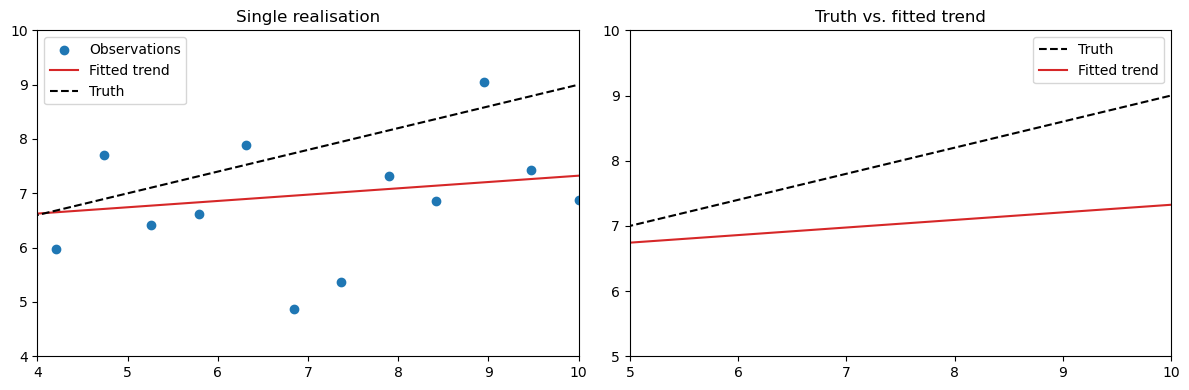

In [2]:
# BLUE function
def blue(A, y, Sigma_Y):
    W = np.linalg.inv(Sigma_Y)
    x_hat = np.linalg.inv(A.T @ W @ A) @ (A.T @ W @ y)
    return x_hat

# Set up observation model
np.random.seed(42)
m = 20
t = np.linspace(0, 10, m)
A = np.column_stack((np.ones(m), t))

# the "true" parameters and "true observations"
x_true = np.array([5.0, 0.4])
sigma = 1.5
Sigma_Y = sigma**2 * np.eye(m)
y_true = A @ x_true

# Generate a single realisation (with noise)
y = A @ x_true + np.random.normal(0, sigma, m)
#estimated parameters
x_hat = blue(A, y, Sigma_Y)
y_hat = A @ x_hat
# Plot the results

# Left: Observations and fit
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(t, y, label='Observations', color='tab:blue')
ax[0].plot(t, y_hat, color='tab:red', label='Fitted trend')
ax[0].plot(t, A @ x_true, 'k--', label='Truth')
ax[0].set_title('Single realisation')
ax[0].legend()
ax[0].set_xlim(4, 10)  # Fixed x-axis limits
ax[0].set_ylim(4, 10)  # Fixed y-axis limits
    
    # Right: True vs fitted
ax[1].plot(t, A @ x_true, 'k--', label='Truth')
ax[1].plot(t, y_hat, color='tab:red', label='Fitted trend')
ax[1].set_title('Truth vs. fitted trend')
ax[1].legend()
ax[1].set_xlim(5, 10)  # Fixed x-axis limits
ax[1].set_ylim(5, 10)  # Fixed y-axis limits
    
plt.tight_layout()
plt.show()

# **Repeated Realisations and Convergence of the Estimator**
  
In the previous chapter, you explored the concept of a Monte Carlo simulation and how repeated sampling can be used to approximate the behaviour of random variables.  

The model above shows one possible *realisation* of our noisy observation vector $Y$.
We will now show that if we would repeat the same experiment many times the observations and therefore the fitted model would change. Every repetition gives a new estimate and model: 

$$
\hat{X}_{\text{BLU}}= (\mathrm{A^T} \Sigma_Y^{-1} \mathrm{A})^{-1} \mathrm{A^T} \Sigma_Y^{-1} Y
$$
$$
\hat{X}^{(k)}_{\text{BLU}} 
= 
(\mathrm{A^T}\Sigma_Y^{-1}\mathrm{A})^{-1}
\mathrm{A^T} \Sigma_Y^{-1} Y^{(k)} ,
\qquad 
\hat{Y}^{(k+1)} = \mathrm{A} \hat{x}^{(k)}+ \epsilon^{(k)} ,
$$

where each $\epsilon^{(k)}$ is an independent random sample from  
$\mathcal{N}(0,\,\Sigma_Y)$

Because the BLUE estimator is **unbiased**, the expected value equals the true values:


$$ 
\mathbb{E}[\hat{\mathbf{X}}] = \mathbf{x}_{\text{true}}
$$

This means that if we take many independent samples and compute the **empirical mean**

$$
\bar{\mathbf{x}}_N = \frac{1}{N}\sum_{k=1}^{N}\hat{\mathbf{x}}^{(k)} ,
$$

then as the number of repetitions $N$ increases, the mean will converge to the true mean:

$$
\bar{\mathbf{x}}_N \;\longrightarrow\; \mathbf{x}_{\text{true}} .
$$

In other words, by averaging over many realisations, the random estimation errors cancel out,  
and the mean of all fitted trends converges to the true trend.

Below you can experiment with this principle with the interactive plot.  
Each time you click **“New realisation”**, a new noisy dataset is generated and fitted using BLUE (just like we did in the code above for a single realisation). All realisations are stored and averaged each time you sample again:

* The **left plot** shows the current set of noisy observations and its fitted trend.  
* The **right plot** accumulates all fitted trends and shows their running mean (red) together with the truth.  

Try clicking the `button: New Sample` to add a realisations and see what happens to the red mean line and the black dashed “true” line. (click to resample a couple of times, the more the better)


In [3]:

# BLUE function
def blue(A, y, Sigma_Y):
    W = np.linalg.inv(Sigma_Y)
    x_hat = np.linalg.inv(A.T @ W @ A) @ (A.T @ W @ y)
    return x_hat

# Set up observation model
np.random.seed(42)
m = 20
t = np.linspace(0, 10, m)
A = np.column_stack((np.ones(m), t))

# the "true" parameters and "true observations"
x_true = np.array([5.0, 0.4])
sigma = 1.5
Sigma_Y = sigma**2 * np.eye(m)
y_true = A @ x_true

# Generate a single realisation (with noise)
y = A @ x_true + np.random.normal(0, sigma, m)
#estimated parameters
x_hat = blue(A, y, Sigma_Y)
y_hat = A @ x_hat


# Storage for single realisations results 
x_estimates = []
y_estimates = []

# Plot function for a single realization 
def plot_single_realization(A, t, x_true, sigma, x_estimates):
    y = A @ x_true + np.random.normal(0, sigma, len(t))
    x_hat = blue(A, y, sigma**2 * np.eye(len(t)))
    x_estimates.append(x_hat)
    y_hat = A @ x_hat
    y_estimates.append(y_hat)
    
    # Compute current mean and covariance of estimates
    X_array = np.array(x_estimates)
    x_mean = np.mean(X_array, axis=0)
    
    y_mean_fit = A @ x_mean

    # --- PLOTS ---
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Left: new realization and fitted trend
    ax[0].scatter(t, y, label='Observations', color='tab:blue')
    ax[0].plot(t, y_hat, color='tab:red', label='Fitted model')
    ax[0].plot(t, A @ x_true, 'k--', label='Truth')
    ax[0].set_title(f'Realisation {len(x_estimates)}')
    ax[0].legend()
    ax[0].set_xlim(4, 10)  # Fixed x-axis limits
    ax[0].set_ylim(4, 10)  # Fixed y-axis limits
    
    # Right: mean of all fits so far + 95% conf. region
    ax[1].plot(t, A @ x_true, 'k--', lw=2, label='True trend')
    for i in range(len(y_estimates)):
        ax[1].plot(t, y_estimates[i], 'gray', alpha=0.3)
    ax[1].plot(t, y_mean_fit, 'r-', lw=2, label='Mean fitted model')
    ax[1].set_title(f'Mean model after {len(x_estimates)} realisations')
    ax[1].legend()
    ax[1].set_xlim(5, 10)  # Fixed x-axis limits
    ax[1].set_ylim(5, 10)  # Fixed y-axis limits
    
    plt.tight_layout()
    plt.show()

# Interactive control
out = Output()

def resample(_):
    with out:
        out.clear_output(wait=True)
        plot_single_realization(A, t, x_true, sigma, x_estimates)

# Create button
button = Button(
    description="Click: New sample",
    button_style='info',
    tooltip='Click to generate a new noisy sample and update the mean trend.'
)
button.on_click(resample)

# Display initial realization 
with out:
    plot_single_realization(A, t, x_true, sigma, x_estimates)

# Display button and output area 
display(VBox([button, out]))


You can see the convergence after taking many new samples and if we plot all those individual fitted models we can see grey region being formed, this is a realisation of the confidence region. Lets below take a montecarlo simulation to show what it looks like after many realisations, making $N$ very large. Feel free to move the slider to increase the samples and see what happens with the confidence region after many $N$ realisations.

In [4]:
from ipywidgets import interact, IntSlider
# BLUE function
def blue(A, y, Sigma_Y):
    W = np.linalg.inv(Sigma_Y)
    x_hat = np.linalg.inv(A.T @ W @ A) @ (A.T @ W @ y)
    return x_hat

# Set up observation model
np.random.seed(42)
m = 20
t = np.linspace(0, 10, m)
A = np.column_stack((np.ones(m), t))

# The "true" parameters and "true" observations
x_true = np.array([5.0, 0.4])
sigma = 1.5
Sigma_Y = sigma**2 * np.eye(m)
y_true = A @ x_true

# Function to run N realisations and plot result
def monte_carlo_simulation(N=100):
    x_estimates = []
    y_estimates = []
    
    for _ in range(N):
        y = A @ x_true + np.random.normal(0, sigma, len(t))
        x_hat = blue(A, y, sigma**2 * np.eye(len(t)))
        x_estimates.append(x_hat)
        y_estimates.append(A @ x_hat)
    
    # PLOT
    plt.figure(figsize=(10, 6))  # Larger figure size for better visibility
    
    # Plot N random individual realizations
    for i in range(N):
        plt.plot(t, y_estimates[i], color='gray', alpha=0.3)
    plt.plot(t, A @ x_true, 'b--', lw=2, label='True trend')
    plt.title(f'{N} fitted trends')
    plt.legend()
    plt.xlim(4, 10)
    plt.ylim(4, 11)
    
    plt.tight_layout()
    plt.show()

# Interactive slider for N
interact(monte_carlo_simulation, N=IntSlider(value=10, min=1, max=2000, step=10, description='Realisations'));

interactive(children=(IntSlider(value=10, description='Realisations', max=2000, min=1, step=10), Output()), _d…